/tmp/ipykernel_154/3198572660.py:24: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(calc)


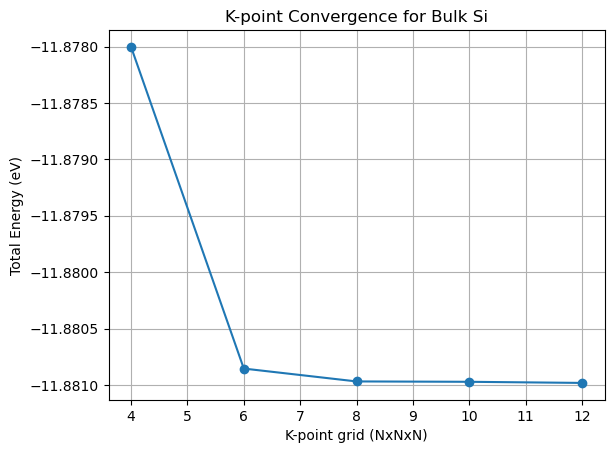

In [3]:
from ase.build import bulk
from ase.optimize import BFGS
from gpaw import GPAW, PW, FermiDirac
import matplotlib.pyplot as plt

# Step 1: Set up bulk Si structure
si_bulk = bulk('Si', 'diamond', a=5.43)  # Silicon in a diamond cubic structure with lattice constant 5.43 Å

# Define k-point grids to test
kpoint_grids = [(4, 4, 4), (6, 6, 6), (8, 8, 8), (10, 10, 10), (12, 12, 12)]

# Store results
energies = []

# Loop over k-point grids
for kpts in kpoint_grids:
    # Step 2: Set up GPAW calculator for each k-point grid
    calc = GPAW(mode=PW(250),                # Plane-wave cutoff energy
                xc='LDA',                    # Exchange-correlation functional
                kpts=kpts,                   # Current k-point grid
                occupations=FermiDirac(0.1), # Smearing for metallic systems
                txt=f'si_bulk_kpts_{kpts[0]}x{kpts[1]}x{kpts[2]}.txt')  # Output file

    si_bulk.set_calculator(calc)

    # Step 3: Perform the self-consistent calculation
    energy = si_bulk.get_potential_energy()
    energies.append(energy)

    # Clean up the calculator for the next iteration
#     calc.write(f'si_bulk_kpts_{kpts[0]}x{kpts[1]}x{kpts[2]}.gpw')
    del calc  # Ensure the old calculator doesn't persist in memory

# Step 4: Plot the k-point convergence
plt.plot([k[0] for k in kpoint_grids], energies, marker='o')
plt.xlabel('K-point grid (NxNxN)')
plt.ylabel('Total Energy (eV)')
plt.title('K-point Convergence for Bulk Si')
plt.grid(True)
plt.show()


/tmp/ipykernel_154/2874066409.py:27: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(calc)


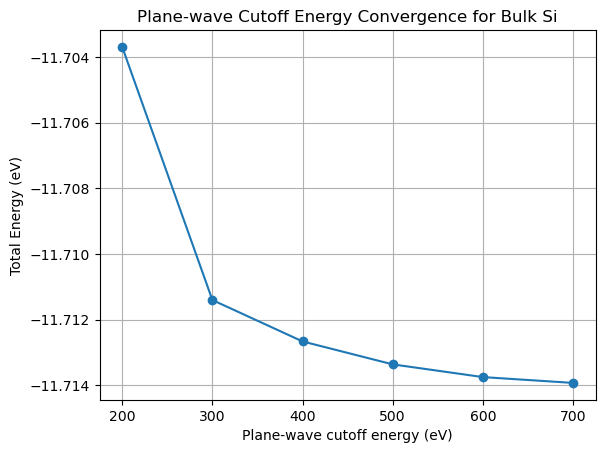

In [4]:
from ase.build import bulk
from gpaw import GPAW, PW, FermiDirac
import matplotlib.pyplot as plt

# Step 1: Set up bulk Si structure
si_bulk = bulk('Si', 'diamond', a=5.43)  # Silicon in a diamond cubic structure with lattice constant 5.43 Å

# Define a range of plane-wave cutoff energies (in eV) to test
ecut_values = [200, 300, 400, 500, 600, 700]

# Smallest k-point grid to use for the scan
kpts = (2, 2, 2)

# Store results
energies = []

# Loop over plane-wave cutoff energies
for ecut in ecut_values:
    # Step 2: Set up GPAW calculator for each energy cutoff
    calc = GPAW(mode=PW(ecut),                # Plane-wave cutoff energy
                xc='LDA',                    # Exchange-correlation functional
                kpts=kpts,                   # Fixed k-point grid
                occupations=FermiDirac(0.1), # Smearing for metallic systems
                txt=f'si_bulk_ecut_{ecut}.txt')  # Output file

    # Attach the calculator to the structure
    si_bulk.set_calculator(calc)

    # Step 3: Perform the self-consistent calculation to get potential energy
    energy = si_bulk.get_potential_energy()
    energies.append(energy)

    # Clean up the calculator for the next iteration
    calc.write(f'si_bulk_ecut_{ecut}.gpw')
    del calc  # Free memory

# Step 4: Plot the plane-wave energy cutoff convergence
plt.plot(ecut_values, energies, marker='o')
plt.xlabel('Plane-wave cutoff energy (eV)')
plt.ylabel('Total Energy (eV)')
plt.title('Plane-wave Cutoff Energy Convergence for Bulk Si')
plt.grid(True)
plt.show()


## Different Bases

### Plane-Wave Basis Set (PW)
Description: Uses plane waves (sine and cosine functions) as basis functions. These are delocalized over the entire simulation cell.

Advantages:
- Suitable for periodic systems (e.g., crystals).
- Basis set is systematically improvable by increasing the energy cutoff.
- No bias toward specific atomic geometries.
Disadvantages:

- Computationally expensive for large vacuum regions (e.g., isolated molecules).
- Requires pseudopotentials to represent core electrons efficiently.

### Linear Combination of Atomic Orbitals (LCAO)
Description: Uses localized atomic orbitals as basis functions, such as Gaussian-type orbitals or numerical solutions to atomic Schrödinger equations.

Advantages:
- Computationally efficient for systems with localized electronic density (e.g., molecules).
- Naturally describes core and valence electrons without pseudopotentials.
- Requires fewer basis functions compared to PW.

Disadvantages:
- Fixed basis sets can introduce bias or limit accuracy.
- Basis sets are not as systematically improvable as plane waves.


### Real-Space Grids
Description: Real-space grid methods discretize the Schrödinger equation on a grid of points in real space, avoiding explicit basis functions like plane waves or atomic orbitals.

Advantages:
- Naturally suited for both periodic and non-periodic systems.
- Can handle complex boundary conditions, localized systems, and large vacuum regions.
- Systematically improvable by refining the grid spacing.

Disadvantages:
- Computational cost scales poorly with system size, as it depends on the number of grid points.
- Requires careful convergence testing with respect to grid spacing.
- Grid-based algorithms often demand higher memory and computational resources compared to PW or LCAO.




### Summary: How to Evaluate the Methods

Accuracy:
- Real-space grids and PW are systematically improvable by refining the grid spacing or increasing the plane-wave cutoff.
- LCAO depends on the predefined basis set and can miss some features.

Efficiency:
- LCAO is efficient for molecular or localized systems.
- PW is efficient for periodic systems but costly for large vacuum regions.
- Real-space grids are computationally intensive but flexible for a wide range of systems.


Usability:
- PW is widely used for periodic materials and crystalline structures.
- LCAO is ideal for quick calculations on localized systems.
- Real-space grids are a versatile choice for unusual or mixed boundary conditions.


| **Property**                     | **PW**                          | **LCAO**                        | **Real-Space Grids**              |
|-----------------------------------|----------------------------------|----------------------------------|-----------------------------------|
| **Basis Representation**         | Delocalized plane waves          | Localized atomic orbitals        | Discrete grid points in real space|
| **Accuracy**                      | High with systematic improvement | Limited by predefined basis set  | High with systematic improvement  |
| **Efficiency for Molecules**      | Poor (large vacuum regions costly) | Excellent (small basis size)    | Moderate                         |
| **Efficiency for Periodic Systems** | Excellent                      | Good                            | Moderate                         |
| **Computational Cost Scaling**    | \(N^3\) (Fourier transforms)     | \(N^2\) or better               | \(N^3\) (depends on grid size)    |
| **Suitability for Complex Systems** | Moderate (requires pseudopotentials) | Limited by predefined basis    | Excellent                        |
| **Convergence Control**           | Energy cutoff                   | Basis set quality                | Grid spacing                     |


In [8]:
from ase.build import bulk
from gpaw import GPAW, PW, LCAO, FermiDirac

# Set up bulk Si structure
si_bulk = bulk('Si', 'diamond', a=5.43)

# Plane-Wave Calculation
pw_calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy
               xc='LDA',                    # Exchange-correlation functional
               kpts=(4, 4, 4),              # k-point grid
               occupations=FermiDirac(0.1),
               txt='si_pw.txt')
si_bulk.set_calculator(pw_calc)
pw_energy = si_bulk.get_potential_energy()
pw_calc.write('si_pw.gpw')

# LCAO Calculation
lcao_calc = GPAW(mode=LCAO(),               # LCAO mode
                 xc='LDA',
                 kpts=(4, 4, 4),
                 occupations=FermiDirac(0.1),
                 txt='si_lcao.txt')
si_bulk.set_calculator(lcao_calc)
lcao_energy = si_bulk.get_potential_energy()
lcao_calc.write('si_lcao.gpw')

# Real-Space Grid Calculation
grid_calc = GPAW(h=0.2,                     # Grid spacing in Å
                 xc='LDA',
                 kpts=(4, 4, 4),            # Same k-point grid for consistency
                 occupations=FermiDirac(0.1),
                 txt='si_real_space.txt')
si_bulk.set_calculator(grid_calc)
grid_energy = si_bulk.get_potential_energy()
grid_calc.write('si_real_space.gpw')

# Output results
print(f"PW Energy: {pw_energy:.6f} eV")
print(f"LCAO Energy: {lcao_energy:.6f} eV")
print(f"Real-Space Grid Energy: {grid_energy:.6f} eV")


/tmp/ipykernel_154/1690316578.py:13: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(pw_calc)
/tmp/ipykernel_154/1690316578.py:23: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(lcao_calc)
/tmp/ipykernel_154/1690316578.py:33: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(grid_calc)


PW Energy: -11.882267 eV
LCAO Energy: -10.298859 eV
Real-Space Grid Energy: -11.872328 eV


### 1. Reference Frame and Accuracy
- Plane-Wave (PW) energies are systematically improvable by increasing the plane-wave cutoff and k-point density. This makes them a reliable reference for accuracy, particularly for periodic systems with delocalized electronic states.
- LCAO energies depend on the quality and completeness of the basis set. While efficient, the predefined basis set may introduce bias or fail to capture all features of the electronic wavefunction.
- Real-Space Grids offer systematically improvable accuracy by refining the grid spacing. This method avoids basis set bias and handles localized and delocalized states equally well. It is particularly advantageous for complex geometries or mixed boundary conditions.

##### Key Insight: Differences in total energy between the methods (PW, LCAO, Real-Space) often reflect the limitations or biases of the basis set, grid spacing, or computational method rather than inherent flaws in the approaches.

### 2. Absolute Energies vs. Relative Energies
- Absolute Energies: The total energies calculated by different methods cannot be directly compared because they depend on the underlying basis set, grid spacing, or computational approach.
- Relative Energies: For most practical applications (e.g., adsorption energies, reaction barriers, phase stability), relative differences between states are what matter. If PW, LCAO, and real-space methods yield consistent relative energies, any of them can be used for the application.
- Real-space grids and PW methods allow systematic convergence of absolute energies by improving grid spacing or increasing the plane-wave cutoff. LCAO is more limited in absolute accuracy due to basis set biases.

### 3. Computational Efficiency vs. Accuracy

##### Plane-Wave (PW):
Best for: High-accuracy calculations for periodic systems like bulk crystals, surfaces, or interfaces.

Limitation: Computationally expensive for systems with large vacuum regions or non-periodic systems.

##### LCAO:
Best for: Efficient calculations on molecules or small, localized systems. Quick screening tasks where relative trends are more critical than absolute accuracy.

Limitation: Accuracy limited by predefined basis sets, which may fail to describe delocalized electronic states accurately.

##### Real-Space Grids:
Best for: Systems with complex or mixed boundary conditions (e.g., defects, isolated systems in vacuum).

Limitation: Computational cost scales poorly with system size due to the cubic scaling of grid density.


In [19]:
from ase.build import bulk
from ase.optimize import BFGS
from gpaw import GPAW, PW, FermiDirac
import sys
import time

# Step 1: Set up bulk Si structure with a conventional cubic cell
initial_lattice_constant = 5.43

si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant, cubic=True)

# Step 2: Set up the GPAW calculator in PW mode
calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy
            xc='LDA',                    # Exchange-correlation functional
            kpts=(4, 4, 4),              # k-point grid
            occupations=FermiDirac(0.1),
            txt='si_ion_relaxation.txt')
si_bulk.set_calculator(calc)

# Step 3: Optimize the lattice parameter by relaxing the cell volume
relax = BFGS(si_bulk, logfile=sys.stdout)  # Print optimization steps to console


# Time the optimization
start_time = time.time()
relax.run(fmax=0.005)  # Converge forces below 0.005 eV/Å
end_time = time.time()

elapsed_time = end_time - start_time
print(f"Time taken for optimization: {elapsed_time:.2f} seconds")

# Save the final structure and calculation results
calc.write('si_relaxed.gpw')


/tmp/ipykernel_154/3556873746.py:17: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(calc)


      Step     Time          Energy          fmax
BFGS:    0 12:31:56      -47.530835        0.000110
Relaxed lattice constant for Si: 5.430000 Å
Time taken for optimization: 25.83 seconds


In [20]:
from ase.build import bulk
from ase.optimize import FIRE
from gpaw import GPAW, PW, FermiDirac
import sys

# Step 1: Set up bulk Si structure with a conventional cubic cell
initial_lattice_constant = 5.43
si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant, cubic=True)

# Step 2: Set up the GPAW calculator in PW mode
calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy
            xc='LDA',                    # Exchange-correlation functional
            kpts=(4, 4, 4),              # k-point grid
            occupations=FermiDirac(0.1),
            txt='si_ion_relaxation.txt')
si_bulk.set_calculator(calc)

# Step 3: Optimize the lattice parameter using FIRE
relax = FIRE(si_bulk, logfile=sys.stdout)  # Print optimization steps to console

# Time the optimization
start_time = time.time()
relax.run(fmax=0.005)  # Converge forces below 0.005 eV/Å
end_time = time.time()


elapsed_time = end_time - start_time
print(f"Time taken for optimization: {elapsed_time:.2f} seconds")

# Save the final structure and calculation results
calc.write('si_relaxed.gpw')


/tmp/ipykernel_154/489607090.py:16: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(calc)


      Step     Time          Energy          fmax
FIRE:    0 12:32:56      -47.530835        0.000110
Relaxed lattice constant for Si: 5.430000 Å
Time taken for optimization: 22.25 seconds


In [23]:
from ase.build import bulk
from ase.optimize import FIRE
from ase.constraints import UnitCellFilter
from gpaw import GPAW, PW, FermiDirac
import sys
import time

# Step 1: Set up bulk Si structure with an initial lattice constant
initial_lattice_constant = 5.4
si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant, cubic=True)

# Step 2: Set up the GPAW calculator in PW mode
calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy
            xc='LDA',                    # Exchange-correlation functional
            kpts=(4, 4, 4),              # k-point grid
            occupations=FermiDirac(0.1), # Smearing for occupation
            txt='si_volume_relaxation.txt')
si_bulk.set_calculator(calc)

# Step 3: Apply a UnitCellFilter for simultaneous cell and atomic relaxation
ucf = UnitCellFilter(si_bulk)  # Enables relaxation of both atomic positions and cell parameters

# Step 4: Optimize the lattice parameter using FIRE optimizer
relax = FIRE(ucf, logfile=sys.stdout)  # Print optimization steps to console

# Time the optimization
start_time = time.time()
relax.run(fmax=0.02)  # Converge forces below 0.01 eV/Å
end_time = time.time()

# Step 5: Output the relaxed lattice constant and elapsed time
final_lattice_constant = si_bulk.cell.lengths()[0]  # Assuming a cubic cell
elapsed_time = end_time - start_time
print(f"Relaxed lattice constant for Si: {final_lattice_constant:.6f} Å")
print(f"Time taken for optimization: {elapsed_time:.2f} seconds")

# Save the final structure and calculation results
calc.write('si_relaxed_volume.gpw')


/tmp/ipykernel_154/3058421364.py:18: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(calc)
/tmp/ipykernel_154/3058421364.py:21: FutureWarning: Import UnitCellFilter from ase.filters
  ucf = UnitCellFilter(si_bulk)  # Enables relaxation of both atomic positions and cell parameters


      Step     Time          Energy          fmax
FIRE:    0 12:44:18      -47.538427        0.040994
FIRE:    1 12:45:04      -47.538476        0.039375
FIRE:    2 12:45:45      -47.538566        0.035830
FIRE:    3 12:46:20      -47.538681        0.030701
FIRE:    4 12:47:16      -47.538799        0.024094
FIRE:    5 12:47:42      -47.538908        0.016112
Relaxed lattice constant for Si: 5.403749 Å
Time taken for optimization: 238.66 seconds


In [24]:
from ase.build import bulk
from ase.optimize import FIRE
from ase.constraints import UnitCellFilter
from gpaw import GPAW, PW, FermiDirac
import sys
import time

# Step 1: Set up bulk Si structure with an initial lattice constant
initial_lattice_constant = 5.43
si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant, cubic=True)

# Step 2: Set up the GPAW calculator in PW mode
calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy
            xc='LDA',                    # Exchange-correlation functional
            kpts=(4, 4, 4),              # k-point grid
            occupations=FermiDirac(0.1), # Smearing for occupation
            txt='si_volume_relaxation.txt')
si_bulk.set_calculator(calc)

# Step 3: Apply a UnitCellFilter for simultaneous cell and atomic relaxation
ucf = UnitCellFilter(si_bulk)  # Enables relaxation of both atomic positions and cell parameters

# Step 4: Optimize the lattice parameter using FIRE optimizer
relax = FIRE(ucf, logfile=sys.stdout)  # Print optimization steps to console

# Time the optimization
start_time = time.time()
relax.run(fmax=0.02)  # Converge forces below 0.01 eV/Å
end_time = time.time()

# Step 5: Output the relaxed lattice constant and elapsed time
final_lattice_constant = si_bulk.cell.lengths()[0]  # Assuming a cubic cell
elapsed_time = end_time - start_time
print(f"Relaxed lattice constant for Si: {final_lattice_constant:.6f} Å")
print(f"Time taken for optimization: {elapsed_time:.2f} seconds")

# Save the final structure and calculation results
calc.write('si_relaxed_volume.gpw')


/tmp/ipykernel_154/1110267348.py:18: DeprecationWarning: Please use atoms.calc = calc
  si_bulk.set_calculator(calc)
/tmp/ipykernel_154/1110267348.py:21: FutureWarning: Import UnitCellFilter from ase.filters
  ucf = UnitCellFilter(si_bulk)  # Enables relaxation of both atomic positions and cell parameters


      Step     Time          Energy          fmax
FIRE:    0 12:53:09      -47.530835        0.154708
FIRE:    1 12:53:44      -47.531539        0.148485
FIRE:    2 12:54:42      -47.532822        0.135333
FIRE:    3 12:55:13      -47.534472        0.116219
FIRE:    4 12:55:48      -47.536189        0.091875
FIRE:    5 12:56:27      -47.537681        0.063229
FIRE:    6 12:56:54      -47.538686        0.031508
FIRE:    7 12:57:28      -47.538993        0.001635
Relaxed lattice constant for Si: 5.405912 Å
Time taken for optimization: 286.67 seconds


## Notes: Difference Between FIRE and BFGS

### 1. Methodology

#### FIRE (Fast Inertial Relaxation Engine):

- A molecular dynamics-based optimization method.
- Combines energy minimization with velocity damping to achieve efficient optimization.
- Particularly effective for systems with noisy or complex potential energy surfaces.


#### BFGS (Broyden-Fletcher-Goldfarb-Shanno):

- A quasi-Newton method that builds an approximate Hessian matrix (second derivatives of the energy) to guide optimization.
- Very efficient for smooth potential energy surfaces and systems with small numbers of degrees of freedom.

### 2. Convergence Behavior

#### FIRE:

- Tends to be more robust for noisy or less well-behaved systems (e.g., during initial stages of structural optimization).
- May require more steps than BFGS but handles large forces or non-smooth gradients better.

#### BFGS:

- Converges more rapidly for well-behaved, smooth potential energy surfaces.
- May struggle in the presence of noise or large initial forces.

### 3. Use Cases

#### Use FIRE for:

- Complex systems, such as surfaces, interfaces, or molecules with challenging initial geometries.
- Situations where initial forces are high or the potential energy surface is noisy.

#### Use BFGS for:

- Bulk systems or periodic structures with well-behaved potential energy surfaces.
- Systems that require fewer optimization steps for convergence.

/tmp/ipykernel_154/2659875123.py:28: DeprecationWarning: Please use atoms.calc = calc
  si_scaled.set_calculator(calc)
/tmp/ipykernel_154/2659875123.py:43: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  lattice_constant_equilibrium = (v0 / si_bulk.get_number_of_atoms()) ** (1 / 3) * 2  # For cubic structure


Bulk modulus: 82.15 GPa


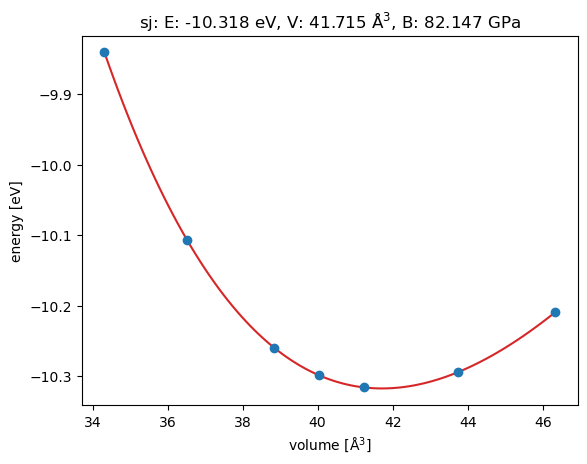

Equilibrium lattice constant: 5.505341 Å
Equilibrium volume: 41.715045 Å³
Bulk modulus: 82.15 GPa


In [33]:
from ase.build import bulk
from gpaw import GPAW, LCAO, FermiDirac
from ase.eos import EquationOfState
import matplotlib.pyplot as plt

# Step 1: Set up bulk Si structure
initial_lattice_constant = 5.43
si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant)

# Step 2: Define scaling factors for lattice and initialize arrays
scaling_factors = [0.95, 0.97, 0.99, 1.0, 1.01, 1.03, 1.05]  # Scale the lattice from 95% to 105%
energies = []
volumes = []

# Step 3: Calculate total energy for each scaled structure
for scale in scaling_factors:
    # Scale the lattice
    si_scaled = si_bulk.copy()
    si_scaled.set_cell(si_scaled.cell * scale, scale_atoms=True)
    volume = si_scaled.get_volume()

    # Set up GPAW calculator in LCAO mode with k-points
    calc = GPAW(mode=LCAO(),
                xc='LDA',
                kpts=(4, 4, 4),  # Add a k-point grid
                occupations=FermiDirac(0.1),
                txt=f'si_lcao_{scale:.2f}.txt')
    si_scaled.set_calculator(calc)

    # Calculate total energy
    energy = si_scaled.get_potential_energy()
    energies.append(energy)
    volumes.append(volume)

    # Clean up calculator
    del calc

# Step 4: Use ASE's EquationOfState to fit the data
eos = EquationOfState(volumes, energies)  # No eos_type keyword needed
v0, e0, B = eos.fit()  # v0: equilibrium volume, e0: minimum energy, B: bulk modulus

# Step 5: Calculate equilibrium lattice constant
lattice_constant_equilibrium = (v0 / si_bulk.get_number_of_atoms()) ** (1 / 3) * 2  # For cubic structure



# Step 6: Plot the EOS fit
eos.plot('eos_fit_si.png')  # Save the plot to a file
plt.show()

# Step 7: Output results
print(f"Equilibrium lattice constant: {lattice_constant_equilibrium:.6f} Å")
print(f"Equilibrium volume: {v0:.6f} Å³")

bulk_modulus_gpa = B * 160.21766208  # Convert bulk modulus eV/Å³ to GPa
print(f"Bulk modulus: {bulk_modulus_gpa:.2f} GPa")


/tmp/ipykernel_154/2936884.py:28: DeprecationWarning: Please use atoms.calc = calc
  si_scaled.set_calculator(calc)
/tmp/ipykernel_154/2936884.py:43: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  lattice_constant_equilibrium = (v0 / si_bulk.get_number_of_atoms()) ** (1 / 3) * 2  # For cubic structure


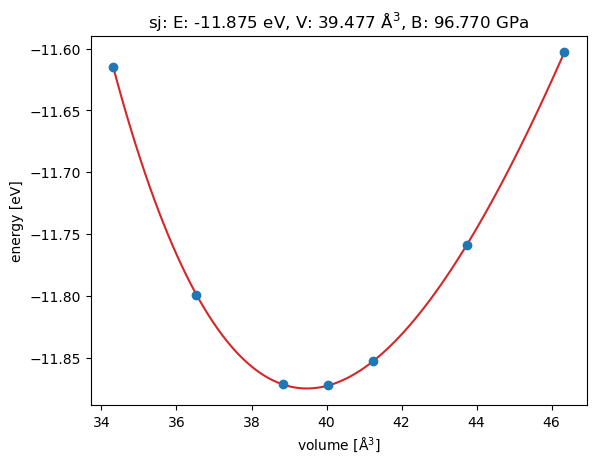

Equilibrium lattice constant: 5.405053 Å
Equilibrium volume: 39.476614 Å³
Bulk modulus: 96.77 GPa


In [39]:
from ase.build import bulk
from gpaw import GPAW, FermiDirac
from ase.eos import EquationOfState
import matplotlib.pyplot as plt

# Step 1: Set up bulk Si structure
initial_lattice_constant = 5.43
si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant)

# Step 2: Define scaling factors for lattice and initialize arrays
scaling_factors = [0.95, 0.97, 0.99, 1.0, 1.01, 1.03, 1.05]  # Scale the lattice from 95% to 105%
energies = []
volumes = []

# Step 3: Calculate total energy for each scaled structure
for scale in scaling_factors:
    # Scale the lattice
    si_scaled = si_bulk.copy()
    si_scaled.set_cell(si_scaled.cell * scale, scale_atoms=True)
    volume = si_scaled.get_volume()

    # Set up GPAW calculator in real-space grid mode
    calc = GPAW(h=0.2,                     # Grid spacing in Å
                xc='LDA',                  # Exchange-correlation functional
                kpts=(4, 4, 4),            # k-point grid
                occupations=FermiDirac(0.1),
                txt=f'si_real_space_{scale:.2f}.txt')  # Log file
    si_scaled.set_calculator(calc)

    # Calculate total energy
    energy = si_scaled.get_potential_energy()
    energies.append(energy)
    volumes.append(volume)

    # Clean up calculator
    del calc

# Step 4: Use ASE's EquationOfState to fit the data
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()

# Step 5: Calculate equilibrium lattice constant
lattice_constant_equilibrium = (v0 / si_bulk.get_number_of_atoms()) ** (1 / 3) * 2  # For cubic structure

# Step 6: Plot the EOS fit
eos.plot('eos_fit_si_real_space.png')  # Save the plot to a file
plt.show()

# Step 7: Output results
print(f"Equilibrium lattice constant: {lattice_constant_equilibrium:.6f} Å")
print(f"Equilibrium volume: {v0:.6f} Å³")
print(f"Bulk modulus: {B * 160.21766208:.2f} GPa")  # Convert B from eV/Å³ to GPa


/tmp/ipykernel_154/3853705275.py:28: DeprecationWarning: Please use atoms.calc = calc
  si_scaled.set_calculator(calc)
/tmp/ipykernel_154/3853705275.py:43: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  lattice_constant_equilibrium = (v0 / si_bulk.get_number_of_atoms()) ** (1 / 3) * 2  # For cubic structure


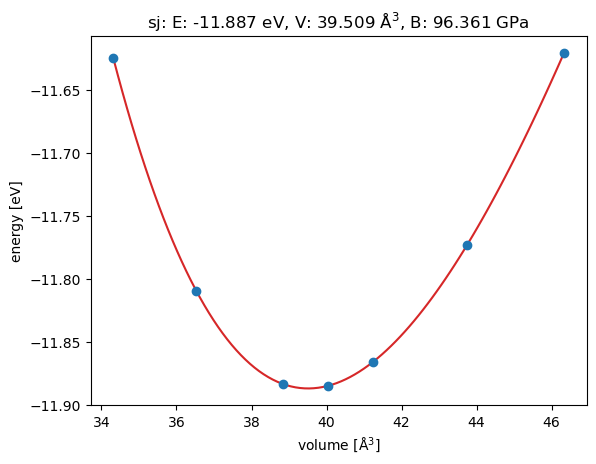

Equilibrium lattice constant (manual relaxation): 5.406523 Å
Equilibrium volume: 39.508839 Å³
Bulk modulus: 96.36 GPa


In [40]:
from ase.build import bulk
from gpaw import GPAW, PW, FermiDirac
from ase.eos import EquationOfState
import matplotlib.pyplot as plt

# Step 1: Set up bulk Si structure
initial_lattice_constant = 5.43
si_bulk = bulk('Si', 'diamond', a=initial_lattice_constant)

# Step 2: Define scaling factors for lattice and initialize arrays
scaling_factors = [0.95, 0.97, 0.99, 1.0, 1.01, 1.03, 1.05]  # Scale the lattice from 95% to 105%
energies = []
volumes = []

# Step 3: Calculate total energy for each scaled structure
for scale in scaling_factors:
    # Scale the lattice
    si_scaled = si_bulk.copy()
    si_scaled.set_cell(si_scaled.cell * scale, scale_atoms=True)
    volume = si_scaled.get_volume()

    # Set up GPAW calculator in PW mode
    calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy in eV
                xc='LDA',                    # Exchange-correlation functional
                kpts=(6, 6, 6),              # k-point grid
                occupations=FermiDirac(0.1),
                txt=f'si_pw_{scale:.2f}.txt')  # Log file
    si_scaled.set_calculator(calc)

    # Calculate total energy
    energy = si_scaled.get_potential_energy()
    energies.append(energy)
    volumes.append(volume)

    # Clean up calculator
    del calc

# Step 4: Use ASE's EquationOfState to fit the data
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()

# Step 5: Calculate equilibrium lattice constant
lattice_constant_equilibrium = (v0 / si_bulk.get_number_of_atoms()) ** (1 / 3) * 2  # For cubic structure

# Step 6: Plot the EOS fit
eos.plot('eos_fit_si_pw.png')  # Save the plot to a file
plt.show()

# Step 7: Output results
print(f"Equilibrium lattice constant (manual relaxation): {lattice_constant_equilibrium:.6f} Å")
print(f"Equilibrium volume: {v0:.6f} Å³")
print(f"Bulk modulus: {B * 160.21766208:.2f} GPa")  # Convert B from eV/Å³ to GPa
